<a href="https://colab.research.google.com/github/ammaraslam67/Final-Year-Project-Aslam1/blob/main/Topic_05_Jan_26_HyperParameter_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Breast Cancer Recurrence: Identifying High-Risk Patients Using Machine Learning Classifiers**

# **Section 1: Import Libraries and File**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# Replace with your local path to the downloaded file
df = pd.read_csv('/mnt/data/Breast_Cancer_METABRIC_Epic_Hospital.csv')

# **Section 2: EDA**

## **Section 2.1: Dataset description and Checking Missignness**

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum()) # Check for missing clinical records

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15054 entries, 0 to 15053
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      15054 non-null  object 
 1   Age at Diagnosis                15054 non-null  float64
 2   Type of Breast Surgery          15048 non-null  object 
 3   Cancer Type                     15054 non-null  object 
 4   Cancer Type Detailed            15054 non-null  object 
 5   Cellularity                     15024 non-null  object 
 6   Chemotherapy                    15054 non-null  object 
 7   Pam50 + Claudin-low subtype     15048 non-null  object 
 8   Cohort                          15048 non-null  float64
 9   ER status measured by IHC       15054 non-null  object 
 10  ER Status                       15054 non-null  object 
 11  Neoplasm Histologic Grade       15054 non-null  int64  
 12  HER2 status measured by SNP6    

## **Section 2.2: Filling missing values**

In [ ]:
# Filling missing continuous values with Median and categorical with Mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## **Section 2.3: Target & Feature Distribution**

/tmp/ipykernel_1288/2155456784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Relapse Free Status', data=df, palette='viridis')


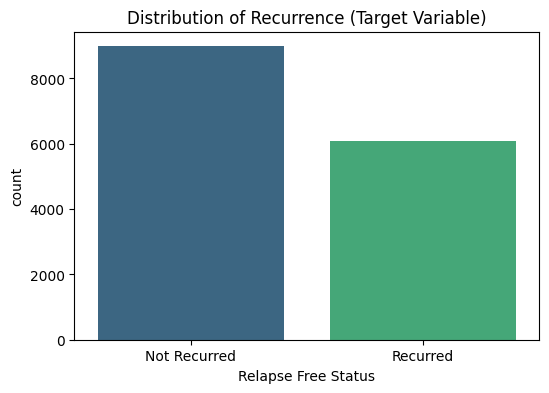

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Relapse Free Status', data=df, palette='viridis')
plt.title('Distribution of Recurrence (Target Variable)')
plt.show()

## **Section 2.4: Correlation Matrix**

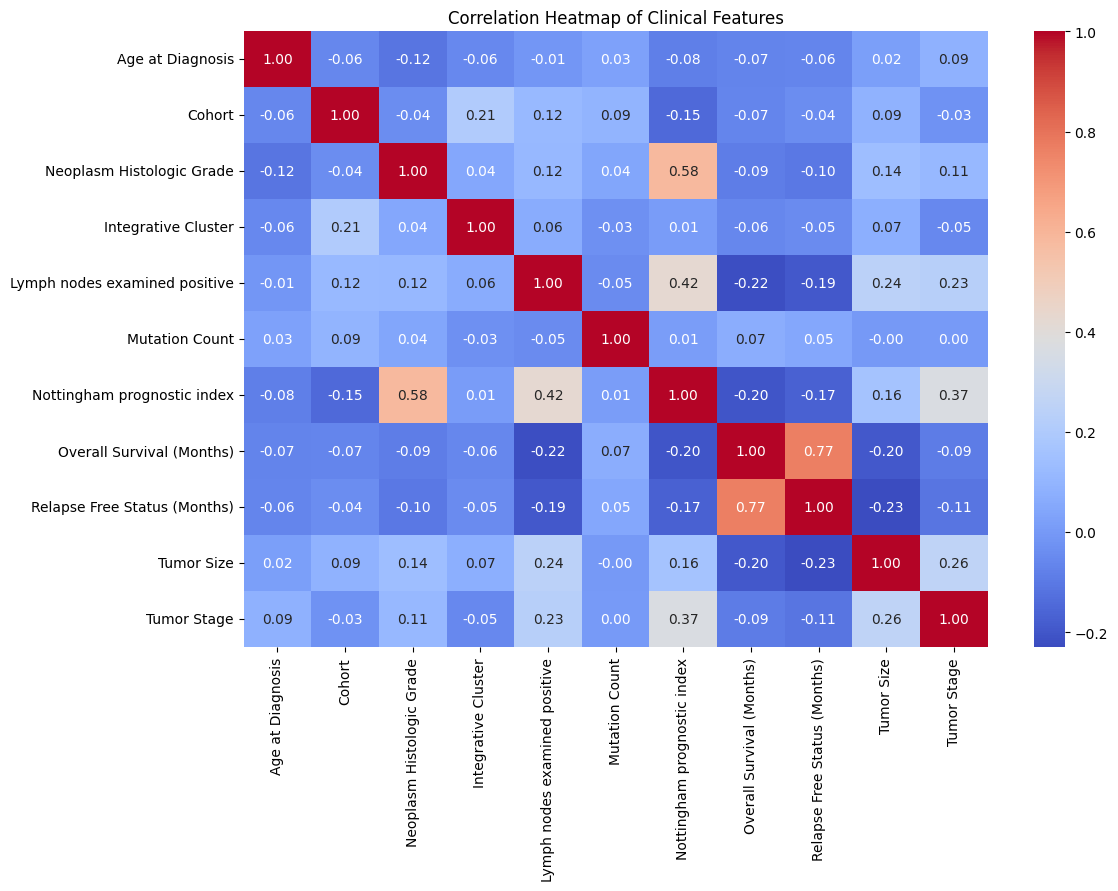

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

# **Section 3: Preprocessing**

## **Section 3.1: Encoding and Handling Imbalance**

In [ ]:
# Encoding categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Relapse Free Status', axis=1)
y = df['Relapse Free Status']

# Handling imbalance to improve sensitivity (RQ1)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

## **Section 3.2: Scaling and Train-Test Division**

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix, recall_score,
                             roc_auc_score, roc_curve, accuracy_score, precision_score, f1_score)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# **Section 4: Model Training & Evaluation**


==================== Random Forest ====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1797
           1       1.00      1.00      1.00      1796

    accuracy                           1.00      3593
   macro avg       1.00      1.00      1.00      3593
weighted avg       1.00      1.00      1.00      3593



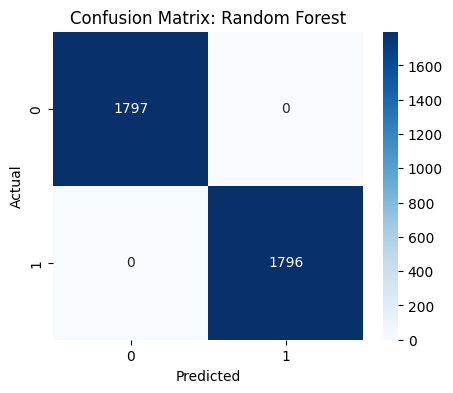

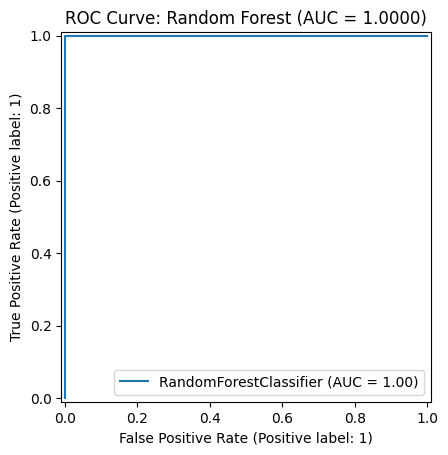


==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1797
           1       0.94      0.88      0.91      1796

    accuracy                           0.91      3593
   macro avg       0.91      0.91      0.91      3593
weighted avg       0.91      0.91      0.91      3593



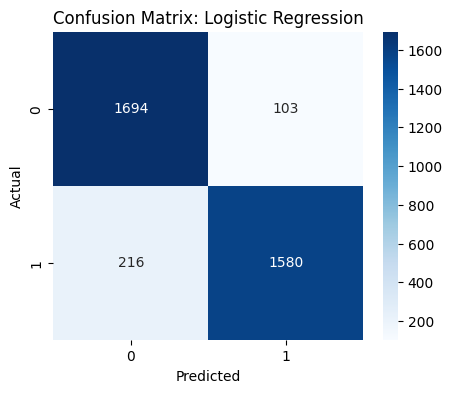

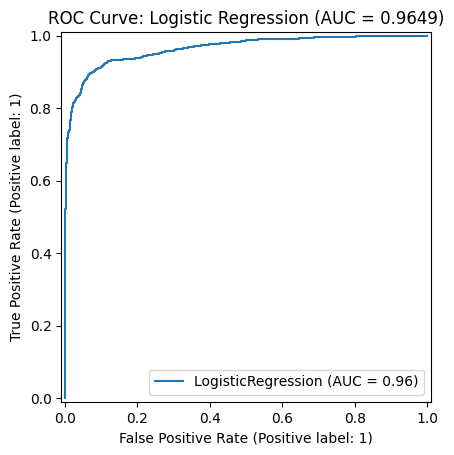


==================== SVM ====================
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1797
           1       0.97      0.95      0.96      1796

    accuracy                           0.96      3593
   macro avg       0.96      0.96      0.96      3593
weighted avg       0.96      0.96      0.96      3593



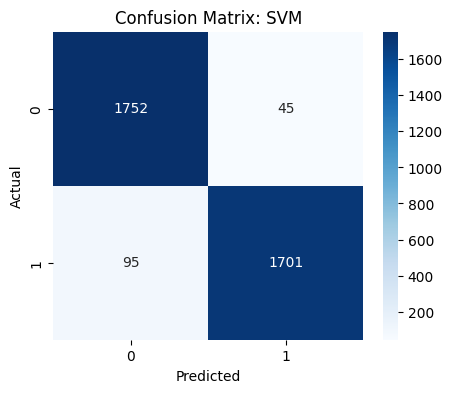

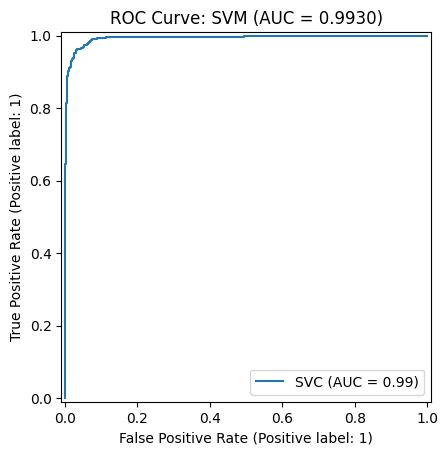

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Define the models to compare as per the project proposal
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, random_state=42)
}

# Dictionary to store results for final summary
summarized_results = []

# Loop through each model for training and detailed evaluation
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"\n{'='*20} {name} {'='*20}")

    # 4.1 Classification Report
    print(classification_report(y_test, y_pred))

    # 4.2 Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # 4.3 ROC-AUC Curve
    if y_prob is not None:
        auc_score = roc_auc_score(y_test, y_prob)
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
        plt.title(f'ROC Curve: {name} (AUC = {auc_score:.4f})')
        plt.show()
    else:
        auc_score = "N/A"

    # 4.4 Store Metrics for Summarization
    summarized_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": auc_score
    })

## **Section 4.1: Visualization of Model Comparision**


FINAL SUMMARIZED METRICS
                 Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  \
0        Random Forest  1.000000   1.000000              1.000000  1.000000   
2                  SVM  0.961035   0.974227              0.947105  0.960474   
1  Logistic Regression  0.911216   0.938800              0.879733  0.908307   

    ROC-AUC  
0  1.000000  
2  0.993029  
1  0.964916  


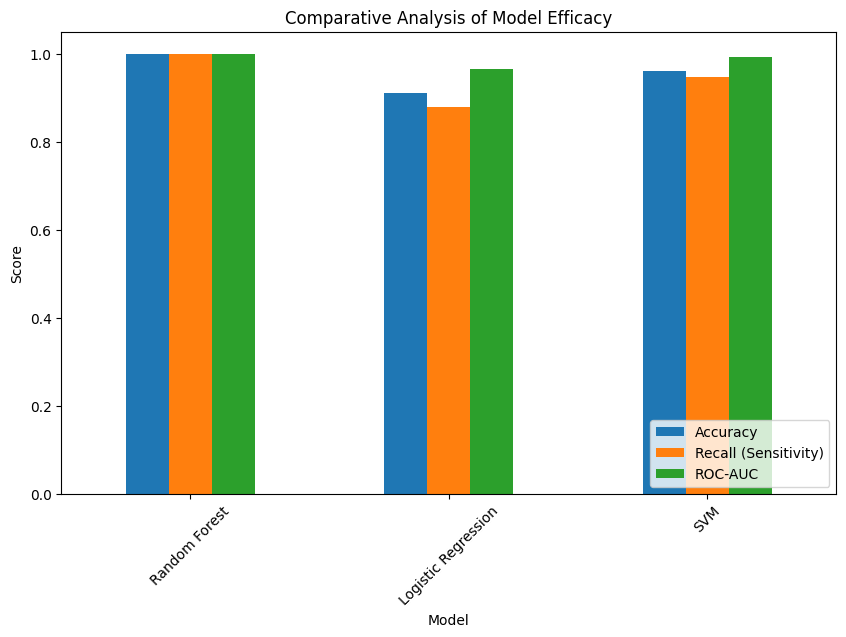

In [ ]:
# Convert the results list into a structured DataFrame
metrics_summary_df = pd.DataFrame(summarized_results)

print("\n" + "="*25)
print("FINAL SUMMARIZED METRICS")
print("="*25)
print(metrics_summary_df.sort_values(by='Recall (Sensitivity)', ascending=False))

# Visualization of Model Comparison
metrics_summary_df.set_index('Model')[['Accuracy', 'Recall (Sensitivity)', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparative Analysis of Model Efficacy')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

# **Section 5: Hyperparameter Tuning using Optuna**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.6 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
def tune_models(trial, model_name):
    if model_name == "Random Forest":
        params = {
            'n_estimators': trial.suggest_int('rf_n_estimators', 100, 300), # Reduced range for speed
            'max_depth': trial.suggest_int('rf_max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 5)
        }
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1) # Parallel execution

    elif model_name == "Logistic Regression":
        params = {
            'C': trial.suggest_float('lr_C', 0.1, 10.0, log=True), # Focused search space
            'solver': 'liblinear' # Fixed solver for binary classification speed
        }
        model = LogisticRegression(**params, max_iter=500)

    elif model_name == "SVM":
        params = {
            'C': trial.suggest_float('svm_C', 0.1, 5.0, log=True),
            'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf']) # Dropped 'poly' to save time
        }
        model = SVC(**params, probability=True, random_state=42)

    # Using 2-fold CV during tuning phase for speed, then 5-fold in final validation
    score = cross_val_score(model, X_train_scaled, y_train, cv=2, scoring='recall', n_jobs=-1).mean()
    return score

best_model_params = {}

for m_name in ["Random Forest", "Logistic Regression", "SVM"]:
    print(f"Accelerated Tuning: {m_name}...")
    # Using 'TPESampler' for faster convergence toward optimal params
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(lambda trial: tune_models(trial, m_name), n_trials=8) # Lower trials for speed
    best_model_params[m_name] = study.best_params

[I 2026-04-22 02:55:34,518] A new study created in memory with name: no-name-2a395a66-8738-4f81-86ca-919f9b7c20c6


Accelerated Tuning: Random Forest...


[I 2026-04-22 02:55:44,520] Trial 0 finished with value: 0.9831617033119955 and parameters: {'rf_n_estimators': 182, 'rf_max_depth': 16, 'rf_min_samples_split': 3}. Best is trial 0 with value: 0.9831617033119955.
[I 2026-04-22 02:55:49,193] Trial 1 finished with value: 0.923462287781798 and parameters: {'rf_n_estimators': 218, 'rf_max_depth': 10, 'rf_min_samples_split': 5}. Best is trial 0 with value: 0.9831617033119955.
[I 2026-04-22 02:55:50,929] Trial 2 finished with value: 0.8188143612580017 and parameters: {'rf_n_estimators': 103, 'rf_max_depth': 5, 'rf_min_samples_split': 4}. Best is trial 0 with value: 0.9831617033119955.
[I 2026-04-22 02:55:58,663] Trial 3 finished with value: 0.9801001948232675 and parameters: {'rf_n_estimators': 264, 'rf_max_depth': 15, 'rf_min_samples_split': 4}. Best is trial 0 with value: 0.9831617033119955.
[I 2026-04-22 02:56:03,103] Trial 4 finished with value: 0.985249095463401 and parameters: {'rf_n_estimators': 180, 'rf_max_depth': 18, 'rf_min_sample

Accelerated Tuning: Logistic Regression...


[I 2026-04-22 02:56:13,814] Trial 1 finished with value: 0.8824102421374895 and parameters: {'lr_C': 0.5975807360555409}. Best is trial 0 with value: 0.8825494016142499.
[I 2026-04-22 02:56:14,035] Trial 2 finished with value: 0.8828277205677706 and parameters: {'lr_C': 4.943364376516585}. Best is trial 2 with value: 0.8828277205677706.
[I 2026-04-22 02:56:14,268] Trial 3 finished with value: 0.8825494016142499 and parameters: {'lr_C': 1.7825941144942283}. Best is trial 2 with value: 0.8828277205677706.
[I 2026-04-22 02:56:14,517] Trial 4 finished with value: 0.8824102421374895 and parameters: {'lr_C': 1.354453028064677}. Best is trial 2 with value: 0.8828277205677706.
[I 2026-04-22 02:56:14,739] Trial 5 finished with value: 0.882966880044531 and parameters: {'lr_C': 5.638827190397993}. Best is trial 5 with value: 0.882966880044531.
[I 2026-04-22 02:56:14,941] Trial 6 finished with value: 0.8804620094628444 and parameters: {'lr_C': 0.11267752876892834}. Best is trial 5 with value: 0.88

Accelerated Tuning: SVM...


[I 2026-04-22 02:56:26,611] Trial 0 finished with value: 0.8812969663234067 and parameters: {'svm_C': 0.33021148075700213, 'svm_kernel': 'linear'}. Best is trial 0 with value: 0.8812969663234067.
[I 2026-04-22 02:56:41,361] Trial 1 finished with value: 0.9301419426662956 and parameters: {'svm_C': 1.1159670057284186, 'svm_kernel': 'rbf'}. Best is trial 1 with value: 0.9301419426662956.
[I 2026-04-22 02:56:55,311] Trial 2 finished with value: 0.9432229334817701 and parameters: {'svm_C': 1.9417821579558725, 'svm_kernel': 'rbf'}. Best is trial 2 with value: 0.9432229334817701.
[I 2026-04-22 02:57:05,194] Trial 3 finished with value: 0.8808794878931255 and parameters: {'svm_C': 0.32042101274033075, 'svm_kernel': 'linear'}. Best is trial 2 with value: 0.9432229334817701.
[I 2026-04-22 02:57:16,362] Trial 4 finished with value: 0.8811578068466462 and parameters: {'svm_C': 0.3294961062114119, 'svm_kernel': 'linear'}. Best is trial 2 with value: 0.9432229334817701.
[I 2026-04-22 02:57:26,406] T